In [58]:
import random
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy

import matplotlib.animation as animation
from operator import itemgetter

In [59]:
random.seed(10)

### Wizualizacja każdego osobnika (każdej trasy) w populacji początkowej

In [60]:
def vizualize(routes):
    fig, ax = plt.subplots()
    ax.set_xlim(min(x_coords) - 1, max(x_coords) + 1)
    ax.set_ylim(min(y_coords) - 1, max(y_coords) + 1)
    x, y = zip(*routes[0])
    line, = ax.plot(x, y, '-o')

    title = ax.set_title("Gen 0")
    
    def update(frame):
        route = routes[frame]
        x, y = zip(*route)
        line.set_data(x, y)
        title.set_text(f"Gen {frame}")
        return line, title
    
    ani = animation.FuncAnimation(fig=fig, func=update, frames=len(routes), blit=False, repeat=True, interval=50) # interval=1000
    
    plt.show()
    
    # Save animation
    ani.save(f"gen.gif", writer="pillow")

### Funkcja oceny osobników

In [61]:
def individual_eval(route):
    dist = 0
    for k in range(1, len(route)):
        dist += np.sqrt(np.sum((np.array(route[k]) - np.array(route[k-1])) ** 2))
    return dist

### Ocena osobników w populacji

In [62]:
def population_eval(routes):
    dist_sums = []
    best_score = float('inf')
    best_route = None
    
    for route in routes:
        score = individual_eval(route)
        dist_sums.append(score)
        
        if score < best_score: 
            best_score = score
            best_route = route.copy()
    
    return dist_sums, best_route


## Selekcja

In [63]:
def ranking_list_selection(pop_eval):
    global N
    enum = list(enumerate(pop_eval))
    sorted_dists = sorted(enum, key=itemgetter(1))
    selected = sorted_dists[:N]
    #print(selected)
    return selected

def roulette_selection(pop_eval):
    return

def tournament_selection(pop_eval, routes, tournament_size=3):
    selected_indices = []
    
    for _ in range(N):
        # Select random subset for tournament
        candidates = random.sample(range(len(routes)), tournament_size)
        # Find the best individual in this tournament
        best_idx = min(candidates, key=lambda idx: pop_eval[idx])
        selected_indices.append(best_idx)
    
    return [(idx, pop_eval[idx]) for idx in selected_indices]

## Generacja populacji potomnej

In [64]:
def parents_population(selected, routes):
    return [routes[i] for i, _ in selected]

## Ewolucja (krzyżowanie, mutacja)

### Krzyżowanie

In [65]:
def crossover(parent1, parent2):
    size = len(parent1) - 1  # bez ostatniego punktu powrotu

    start, end = sorted(random.sample(range(size), 2))
    child = [None] * size

    # copy slice from parent1
    child[start:end] = parent1[start:end]

    # fill from parent2
    p2_filtered = [city for city in parent2 if city not in child]
    idx = 0
    for i in range(size):
        if child[i] is None:
            child[i] = p2_filtered[idx]
            idx += 1

    # dodaj powrót do punktu startowego
    child.append(child[0])
    return child

def order_crossover(parent1, parent2):
    """Order crossover (OX) - Preserves relative ordering of cities."""
    n = len(parent1) - 1  # Exclude the last city (which is a copy of the first)
    
    # Select substring from parent1
    start = random.randrange(n)
    end = random.randrange(start + 1, n + 1)
    
    # Create child with substring from parent1
    child = [None] * n
    for i in range(start, end):
        child[i] = parent1[i]
    
    # Fill remaining positions with cities from parent2 in order
    parent2_cities = [city for city in parent2[:-1] if city not in child]
    idx = 0
    for i in range(n):
        if child[i] is None:
            child[i] = parent2_cities[idx]
            idx += 1
    
    # Add the closing city (same as first)
    child.append(child[0])
    return child

### Mutacja

In [66]:
def swap_mutation(route, mutation_prob):
    if random.random() > mutation_prob:
        return route
        
    n = len(route) - 1  # Exclude the last city which is a duplicate of first
    
    loc1 = random.randrange(n)
    loc2 = random.randrange(n)
    
    # Ensure locations are different
    while loc1 == loc2:
        loc2 = random.randrange(n)
        
    # Swap cities
    route[loc1], route[loc2] = route[loc2], route[loc1]
    
    # Ensure the route is still a cycle
    route[-1] = route[0]
    
    return route

def insertion_mutation(route, mutation_prob):
    if random.random() > mutation_prob:
        return route
        
    n = len(route) - 1  # Exclude the last city
    
    # Select positions
    loc1 = random.randrange(n)
    loc2 = random.randrange(n)
    
    # Ensure locations are different
    while loc1 == loc2:
        loc2 = random.randrange(n)
    
    # Remove city from loc1 and insert at loc2
    city = route[loc1]
    route.pop(loc1)
    route.insert(loc2, city)
    
    # Ensure the route is still a cycle
    route[-1] = route[0]
    
    return route

## Warunek zakończenia ewolucji

In [67]:
def stop_condition(scores, generation, max_generations=500, patience=30):
    """Stop if reached max generations or if no improvement over several generations."""
    # Stop if we've reached max generations
    if generation >= max_generations:
        return False
    
    # Check for convergence if we have enough history
    if len(scores) >= patience:
        # If no improvement in the last 'patience' generations, stop
        if scores[-patience] <= min(scores[-patience:]):
            return False
    
    return True

## Cykl główny

In [68]:
def main_cycle(routes, route_scores):
    selected = ranking_list_selection(route_scores)
    parents = parents_population(selected, routes)

    offspring = []
    for _ in range(m):
        p1, p2 = random.sample(parents, 2)
        child = crossover(p1, p2)
        if random.random() < mutate_prob:
            child = mutate(child)
        offspring.append(child)

    scores, best_route = population_eval(offspring)
    return offspring, scores, best_route

# Algorytm genetyczny

### Parametry

In [84]:
m = 1000 # liczebność populacji
n = 30 # długość chromosomu (ilość miast do odwiedzenia)
N = m // 2 # liczba najlepszych osobnikow do rozmnazania
mutation_prob = 1/n # prawdopodobienstwo mutacji

Generation 10: Best distance = 1478.42
Generation 20: Best distance = 1270.49
Generation 30: Best distance = 994.12
Generation 40: Best distance = 897.35
Generation 50: Best distance = 858.94
Generation 60: Best distance = 849.74
Generation 70: Best distance = 845.64
Generation 80: Best distance = 845.64
Generation 90: Best distance = 845.64
Final solution: Distance = 845.64 after 94 generations


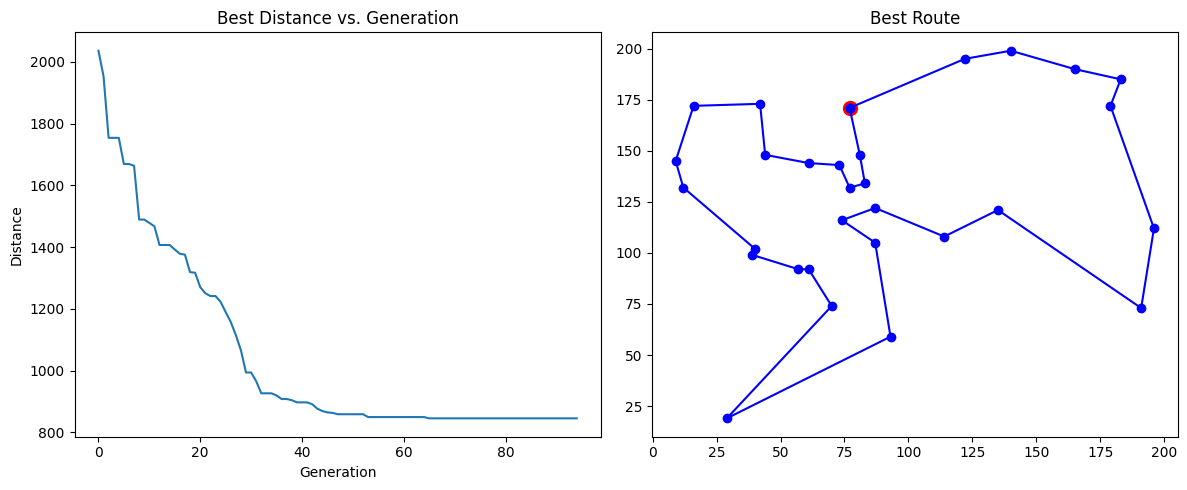

In [85]:
gen = 0

# losowanie populacji poczatkowej P(t) o zadanej liczebnosci
x_coords = [random.randrange(200) for _ in range(n)]
y_coords = [random.randrange(200) for _ in range(n)]
cities = list(zip(x_coords, y_coords))

routes = []
for _ in range(m):
    route_order = random.sample(range(n), n)
    route = [cities[i] for i in route_order]
    route.append(route[0])  # Complete the cycle
    routes.append(route)

# Evaluate initial population
pop_eval, best_route = population_eval(routes)
best_score = min(pop_eval)

# Initialize tracking variables
generation = 0
scores_history = [best_score]
best_routes = [best_route]

# Setup plotting
plt.figure(figsize=(12, 5))

# Main evolution loop
while stop_condition(scores_history, generation):
    generation += 1
    
    # Selection
    selected = tournament_selection(pop_eval, routes)
    
    # Get parents
    parents = parents_population(selected, routes)
    
    # Elitism: keep best solution
    best_idx = pop_eval.index(min(pop_eval))
    elite = routes[best_idx].copy()
    
    # Create next generation
    offspring = [elite]  # Start with elite
    
    # Generate remaining offspring through crossover and mutation
    while len(offspring) < m:
        parent1, parent2 = random.sample(parents, 2)
        
        # Crossover
        child = order_crossover(parent1, parent2)
        
        # Mutation - randomly choose mutation type
        if random.random() < 0.5:
            child = swap_mutation(child, mutation_prob)
        else:
            child = insertion_mutation(child, mutation_prob)
        
        # Add to offspring
        offspring.append(child)
    
    # Replace population
    routes = offspring
    
    # Evaluate new population
    pop_eval, current_best_route = population_eval(routes)
    current_best_score = min(pop_eval)
    
    # Update best solution if needed
    if current_best_score < best_score:
        best_score = current_best_score
        best_route = current_best_route
    
    # Track progress
    scores_history.append(best_score)
    best_routes.append(best_route)
    
    # Print progress occasionally
    if generation % 10 == 0:
        print(f"Generation {generation}: Best distance = {best_score:.2f}")

print(f"Final solution: Distance = {best_score:.2f} after {generation} generations")

# Plotting results
plt.subplot(1, 2, 1)
plt.plot(scores_history)
plt.title('Best Distance vs. Generation')
plt.xlabel('Generation')
plt.ylabel('Distance')

plt.subplot(1, 2, 2)
x = [point[0] for point in best_route]
y = [point[1] for point in best_route]
plt.plot(x, y, 'b-o')
plt.scatter(x[0], y[0], c='red', s=100)  # Highlight starting point
plt.title('Best Route')
plt.tight_layout()
plt.show()

In [ ]:
print(gen)

In [ ]:
vizualize(best_routes)